# 🚕 Pipeline Yellow Taxi NYC — Notebook completo

Este notebook reproduce **exactamente el mismo proceso** que los scripts `src/pipeline.py` (ETL) y `src/modeling.py` (modelado):

1. Carga de **los 5 meses** de `data/raw/`.
2. Renombrado de columnas al español.
3. Validación inicial (tipos, nulos, duplicados, rangos).
4. Limpieza con **reporte de registros perdidos por cada filtro**.
5. Muestreo reproducible a 100.000 registros y guardado del parquet limpio.
6. Ingeniería de características (temporales, velocidad, `es_aeropuerto`, features de costo para EDA y One-Hot Encoding).
7. Prevención de fuga de datos + división cronológica 80/20.
8. Entrenamiento (Regresión Lineal + Random Forest), evaluación y guardado de artefactos.
9. Gráficos de evaluación.
10. Informe y conclusiones.

> Genera **los mismos artefactos** que los scripts: `data/processed/yellow_taxi_limpio.parquet`, los CSV de `data/outputs/`, `models/modelo_final.pkl` y `reports/`.


## 1. Configuración e imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

import warnings
warnings.filterwarnings('ignore')

# Trabajamos desde la RAÍZ del proyecto para usar exactamente las mismas rutas que los scripts
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Directorio de trabajo:', os.getcwd())

Directorio de trabajo: /Users/darko/Desktop/Coding/Gestion_de_datos_para_la_ia


## 2. Carga de datos

Se carga **toda** la carpeta `data/raw/` (5 meses), igual que `cargar_datos()` del pipeline.

In [2]:
ruta_entrada = "data/raw/"
df_bruto = pd.read_parquet(ruta_entrada)
print(f"Dataset crudo cargado: {df_bruto.shape[0]} filas y {df_bruto.shape[1]} columnas.")

Dataset crudo cargado: 16445634 filas y 19 columnas.


## 3. Renombrado de columnas al español

In [3]:
mapeo_columnas = {
    'tpep_pickup_datetime': 'fecha_inicio_viaje',
    'tpep_dropoff_datetime': 'fecha_termino_viaje',
    'passenger_count': 'cantidad_pasajeros',
    'trip_distance': 'distancia_viaje',
    'PULocationID': 'zona_origen',
    'DOLocationID': 'zona_destino',
    'RatecodeID': 'tipo_tarifa',
    'payment_type': 'tipo_pago',
    'fare_amount': 'tarifa_base',
    'tip_amount': 'propina',
    'tolls_amount': 'peajes',
    'total_amount': 'monto_total'
}
df = df_bruto.rename(columns=mapeo_columnas)

# Validación de columnas requeridas con error explícito (igual que el pipeline)
columnas_requeridas = ['fecha_inicio_viaje', 'fecha_termino_viaje', 'cantidad_pasajeros',
                       'distancia_viaje', 'tarifa_base', 'monto_total']
faltantes = [c for c in columnas_requeridas if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas requeridas para la limpieza: {faltantes}")
print("Columnas renombradas correctamente.")

Columnas renombradas correctamente.


## 4. Validación inicial (tipos, nulos, duplicados, rangos)

In [4]:
print("Shape:", df.shape)
print("\nVista previa (head):")
display(df.head())

print("\nTipos de datos e info:")
df.info()

print("\nNulos por columna:")
nulos = df.isna().sum()
print(nulos[nulos > 0] if (nulos > 0).any() else "Sin nulos.")

print("\nFilas duplicadas:", df.duplicated().sum())

print("\nRangos de variables numéricas (describe):")
display(df.describe())

Shape: (16445634, 19)

Vista previa (head):


,VendorID,fecha_inicio_viaje,fecha_termino_viaje,cantidad_pasajeros,distancia_viaje,tipo_tarifa,store_and_fwd_flag,zona_origen,zona_destino,tipo_pago,tarifa_base,extra,mta_tax,propina,peajes,improvement_surcharge,monto_total,congestion_surcharge,Airport_fee
0,1,2023-12-01 00:06:06,2023-12-01 00:15:47,0.0,1.10,1.0,N,230,48,1,10.0,3.5,0.5,1.50,0.0,1.0,16.50,2.5,0.0
1,1,2023-12-01 00:22:26,2023-12-01 00:28:53,0.0,1.50,1.0,N,142,238,1,9.3,3.5,0.5,2.85,0.0,1.0,17.15,2.5,0.0
2,1,2023-12-01 00:59:44,2023-12-01 01:13:22,2.0,2.20,1.0,N,114,186,1,13.5,3.5,0.5,3.00,0.0,1.0,21.50,2.5,0.0
3,2,2023-12-01 00:22:17,2023-12-01 00:30:59,1.0,0.66,1.0,N,79,79,2,7.2,1.0,0.5,0.00,0.0,1.0,12.20,2.5,0.0
4,2,2023-12-01 00:18:16,2023-12-01 00:25:32,2.0,2.20,1.0,N,229,263,1,11.4,1.0,0.5,2.00,0.0,1.0,18.40,2.5,0.0



Tipos de datos e info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16445634 entries, 0 to 16445633
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   fecha_inicio_viaje     datetime64[us]
 2   fecha_termino_viaje    datetime64[us]
 3   cantidad_pasajeros     float64       
 4   distancia_viaje        float64       
 5   tipo_tarifa            float64       
 6   store_and_fwd_flag     object        
 7   zona_origen            int32         
 8   zona_destino           int32         
 9   tipo_pago              int64         
 10  tarifa_base            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  propina                float64       
 14  peajes                 float64       
 15  improvement_surcharge  float64       
 16  monto_total            float64       
 17  congestion_surcharge   float64       
 

cantidad_pasajeros      1340541
tipo_tarifa             1340541
store_and_fwd_flag      1340541
congestion_surcharge    1340541
Airport_fee             1340541
dtype: int64



Filas duplicadas: 1

Rangos de variables numéricas (describe):


,VendorID,fecha_inicio_viaje,fecha_termino_viaje,cantidad_pasajeros,distancia_viaje,tipo_tarifa,zona_origen,zona_destino,tipo_pago,tarifa_base,extra,mta_tax,propina,peajes,improvement_surcharge,monto_total,congestion_surcharge,Airport_fee
count,1.644563e+07,16445634,16445634,1.510509e+07,1.644563e+07,1.510509e+07,1.644563e+07,1.644563e+07,1.644563e+07,1.644563e+07,1.644563e+07,1.644563e+07,1.644563e+07,1.644563e+07,1.644563e+07,1.644563e+07,1.510509e+07,1.510509e+07
mean,1.755189e+00,2024-02-16 20:40:46.817151,2024-02-16 20:57:31.229772,1.349963e+00,4.232446e+00,2.116573e+00,1.650390e+02,1.640569e+02,1.122153e+00,1.873867e+01,1.425907e+00,4.830245e-01,3.312817e+00,5.425520e-01,9.751330e-01,2.734375e+01,2.257939e+00,1.394675e-01
min,1.000000e+00,2002-12-31 22:10:04,2002-12-31 22:14:22,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-1.087300e+03,-3.917000e+01,-5.000000e-01,-3.000000e+02,-8.430000e+01,-1.000000e+00,-1.094050e+03,-2.500000e+00,-1.750000e+00
25%,2.000000e+00,2024-01-09 15:02:03.250000,2024-01-09 15:19:20.250000,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.560000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2024-02-19 13:43:49,2024-02-19 13:58:40.500000,1.000000e+00,1.710000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.660000e+00,0.000000e+00,1.000000e+00,2.060000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2024-03-26 21:49:21,2024-03-26 22:03:08.750000,1.000000e+00,3.230000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.120000e+01,2.500000e+00,5.000000e-01,4.200000e+00,0.000000e+00,1.000000e+00,2.976000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2024-05-01 00:02:36,2024-05-01 23:22:35,9.000000e+00,3.127223e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,9.792000e+03,5.168000e+01,4.217000e+01,4.174000e+03,1.702880e+03,1.000000e+00,9.792000e+03,2.500000e+00,1.750000e+00
std,4.319954e-01,NaN,NaN,8.554227e-01,2.949035e+02,1.004021e+01,6.421190e+01,6.952520e+01,6.157652e-01,1.861530e+01,1.811185e+00,1.195389e-01,4.123470e+00,2.201804e+00,2.201385e-01,2.324589e+01,8.259224e-01,4.858269e-01


## 5. Limpieza con reporte de registros perdidos POR CADA filtro

Mismas reglas que `limpiar_y_transformar()`: duplicados, nulos esenciales, positividad de distancia/monto/tarifa/pasajeros, duración válida (0–180 min), coherencia temporal y periodo válido. Se informa cuántos registros elimina **cada** filtro y se guarda en `data/outputs/reporte_limpieza.csv`.

In [5]:
# Fechas y duración
df['fecha_inicio_viaje'] = pd.to_datetime(df['fecha_inicio_viaje'], errors='coerce')
df['fecha_termino_viaje'] = pd.to_datetime(df['fecha_termino_viaje'], errors='coerce')
df['duracion_minutos'] = (df['fecha_termino_viaje'] - df['fecha_inicio_viaje']).dt.total_seconds() / 60.0

n_inicial = len(df)
periodos_validos = pd.PeriodIndex(['2023-12', '2024-01', '2024-02', '2024-03', '2024-04'], freq='M')
reporte = []

# Duplicados exactos
antes = len(df)
df = df.drop_duplicates()
reporte.append({'filtro': 'Filas duplicadas', 'registros_eliminados': antes - len(df), 'registros_restantes': len(df)})

def aplicar(df, nombre, mascara):
    antes = len(df)
    df = df[mascara]
    reporte.append({'filtro': nombre, 'registros_eliminados': antes - len(df), 'registros_restantes': len(df)})
    return df

df = aplicar(df, 'Nulos esenciales', df[['fecha_inicio_viaje', 'fecha_termino_viaje', 'cantidad_pasajeros']].notna().all(axis=1))
df = aplicar(df, 'Distancia > 0', df['distancia_viaje'] > 0)
df = aplicar(df, 'Monto total > 0', df['monto_total'] > 0)
df = aplicar(df, 'Tarifa base > 0', df['tarifa_base'] > 0)
df = aplicar(df, 'Cantidad pasajeros > 0', df['cantidad_pasajeros'] > 0)
df = aplicar(df, 'Duracion > 0 min', df['duracion_minutos'] > 0)
df = aplicar(df, 'Duracion < 180 min', df['duracion_minutos'] < 180)
df = aplicar(df, 'fecha_inicio < fecha_termino', df['fecha_inicio_viaje'] < df['fecha_termino_viaje'])
df = aplicar(df, 'Periodo 2023-12..2024-04', df['fecha_inicio_viaje'].dt.to_period('M').isin(periodos_validos))

df_reporte = pd.DataFrame(reporte)
display(df_reporte)
print(f"Total descartado: {n_inicial - len(df)} de {n_inicial} registros.")

os.makedirs("data/outputs", exist_ok=True)
df_reporte.to_csv("data/outputs/reporte_limpieza.csv", index=False)

# Muestreo reproducible a 100.000 registros
df = df.sample(n=100000, random_state=42)
print("Muestra final:", df.shape)

# Guardar dataset procesado (mismo artefacto que el ETL)
os.makedirs("data/processed", exist_ok=True)
df.to_parquet("data/processed/yellow_taxi_limpio.parquet", index=False)
print("Guardado: data/processed/yellow_taxi_limpio.parquet")

,filtro,registros_eliminados,registros_restantes
0,Filas duplicadas,1,16445633
1,Nulos esenciales,1340541,15105092
2,Distancia > 0,196816,14908276
3,Monto total > 0,181707,14726569
4,Tarifa base > 0,1249,14725320
5,Cantidad pasajeros > 0,181555,14543765
6,Duracion > 0 min,262,14543503
7,Duracion < 180 min,10786,14532717
8,fecha_inicio < fecha_termino,0,14532717
9,Periodo 2023-12..2024-04,42,14532675


Total descartado: 1912959 de 16445634 registros.


Muestra final: (100000, 20)
Guardado: data/processed/yellow_taxi_limpio.parquet


## 6. Ingeniería de características

Idéntica a `crear_features()`: variables temporales, velocidad, `es_aeropuerto`, features de costo **para EDA** (excluidas del entrenamiento) y One-Hot Encoding de categóricas.

In [6]:
# Variables temporales
df['pickup_hour'] = df['fecha_inicio_viaje'].dt.hour
df['pickup_dayofweek'] = df['fecha_inicio_viaje'].dt.dayofweek
df['pickup_month'] = df['fecha_inicio_viaje'].dt.month
df['is_weekend'] = df['pickup_dayofweek'].isin([5, 6]).astype(int)
df['is_rush_hour'] = df['pickup_hour'].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

# Velocidad promedio (mph)
df['velocidad_promedio_mph'] = df['distancia_viaje'] / ((df['duracion_minutos'] + 0.0001) / 60.0)

# Indicador de viaje de aeropuerto (EWR=1, JFK=132, LGA=138)
zonas_aeropuerto = [1, 132, 138]
df['es_aeropuerto'] = (df['zona_origen'].isin(zonas_aeropuerto) |
                       df['zona_destino'].isin(zonas_aeropuerto)).astype(int)

# Features de costo SOLO PARA EDA (derivan de componentes del total -> se excluyen del modelo)
df['tiene_peaje'] = (df['peajes'] > 0).astype(int)
df['tiene_propina'] = (df['propina'] > 0).astype(int)
df['porcentaje_propina'] = (df['propina'] / df['monto_total'].replace(0, np.nan) * 100).fillna(0)
print("Propina promedio (%): {:.1f}  |  Viajes con peaje: {:.1f}%".format(
    df['porcentaje_propina'].mean(), df['tiene_peaje'].mean() * 100))

# One-Hot Encoding de categóricas
categoricas = ['VendorID', 'zona_origen', 'zona_destino', 'tipo_tarifa', 'tipo_pago']
presentes = [c for c in categoricas if c in df.columns]
df = pd.get_dummies(df, columns=presentes, drop_first=True)
print("Shape tras ingeniería de características:", df.shape)

Propina promedio (%): 12.3  |  Viajes con peaje: 7.7%
Shape tras ingeniería de características: (100000, 511)


## 7. Prevención de fuga de datos + división cronológica

Se excluyen del entrenamiento **todos los componentes que suman `monto_total`** y las features de costo de EDA. Luego se ordena por fecha y se divide 80/20 sin barajar (división temporal).

In [7]:
# Componentes que suman monto_total (usarlos seria fuga de datos)
COLUMNAS_LEAKAGE = ['tarifa_base', 'propina', 'peajes', 'extra', 'mta_tax',
                    'improvement_surcharge', 'congestion_surcharge', 'Airport_fee']
# Features de costo creadas solo para EDA (tambien se excluyen)
FEATURES_COSTO_EDA = ['tiene_peaje', 'tiene_propina', 'porcentaje_propina']

# Ordenar cronologicamente antes de dividir
df = df.sort_values('fecha_inicio_viaje')

columnas_a_eliminar = COLUMNAS_LEAKAGE + ['fecha_inicio_viaje', 'fecha_termino_viaje'] + FEATURES_COSTO_EDA
X = df.drop(columns=[c for c in columnas_a_eliminar if c in df.columns])

# Texto (Y/N) -> numerico
if 'store_and_fwd_flag' in X.columns:
    X['store_and_fwd_flag'] = X['store_and_fwd_flag'].map({'Y': 1, 'N': 0}).fillna(0)

# Solo columnas numericas
X = X.select_dtypes(include=[np.number, bool])

# Separar objetivo
y = X.pop('monto_total')

# Division 80/20 cronologica (shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (80000, 497) | Test: (20000, 497)


## 8. Entrenamiento, evaluación y guardado de artefactos

In [8]:
# Modelo baseline: Regresion Lineal
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Modelo avanzado: Random Forest
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# Metricas
metricas = []
for nombre, pred in [("Regresión Lineal", pred_lr), ("Random Forest", pred_rf)]:
    metricas.append({"modelo": nombre,
                     "MAE": mean_absolute_error(y_test, pred),
                     "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
                     "R2": r2_score(y_test, pred)})
df_metricas = pd.DataFrame(metricas)
display(df_metricas)

# Guardar artefactos (mismos que modeling.py)
os.makedirs("models", exist_ok=True)
df_metricas.to_csv("data/outputs/metricas_modelos.csv", index=False)

pd.DataFrame({"valor_real": y_test.values,
              "pred_regresion_lineal": pred_lr,
              "pred_random_forest": pred_rf},
             index=y_test.index).to_csv("data/outputs/predicciones.csv", index=False)

importancias = (pd.DataFrame({"variable": X_train.columns, "importancia": rf.feature_importances_})
                .sort_values("importancia", ascending=False).reset_index(drop=True))
importancias.to_csv("data/outputs/importancia_variables.csv", index=False)

joblib.dump(rf, "models/modelo_final.pkl")
print("Artefactos guardados: metricas_modelos.csv, predicciones.csv, importancia_variables.csv, modelo_final.pkl")

,modelo,MAE,RMSE,R2
0,Regresión Lineal,2.708478,5.558324,0.937686
1,Random Forest,2.028239,4.425246,0.960502


Artefactos guardados: metricas_modelos.csv, predicciones.csv, importancia_variables.csv, modelo_final.pkl


## 9. Gráficos de evaluación (Parte 6: análisis visual)

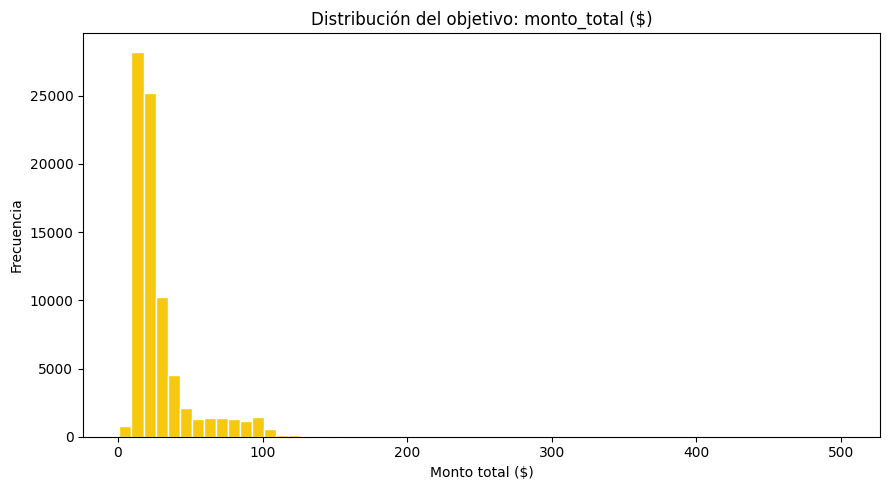

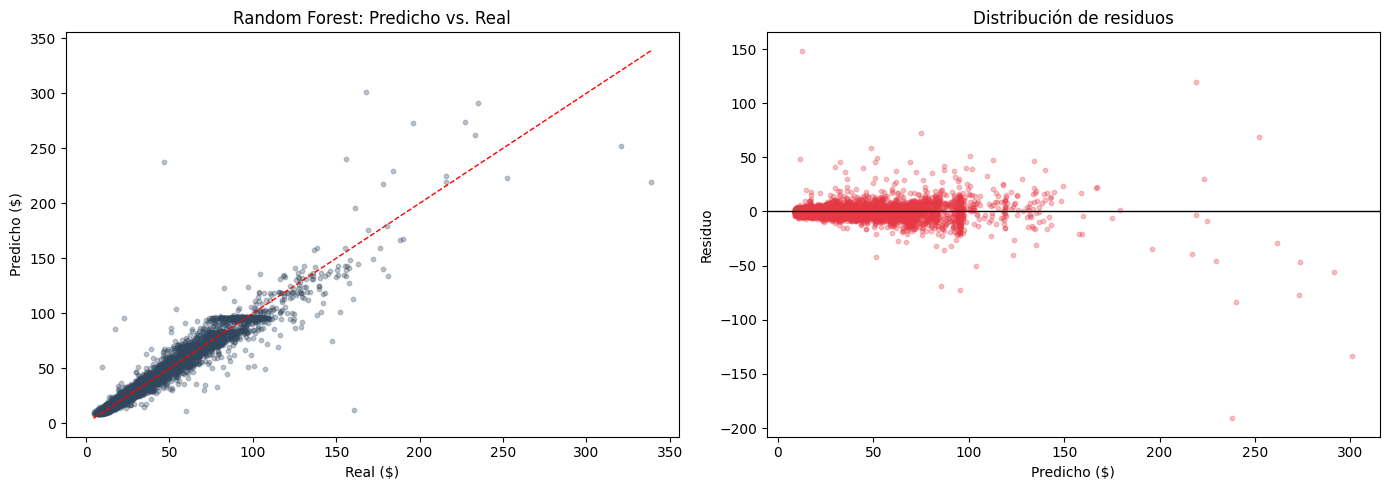

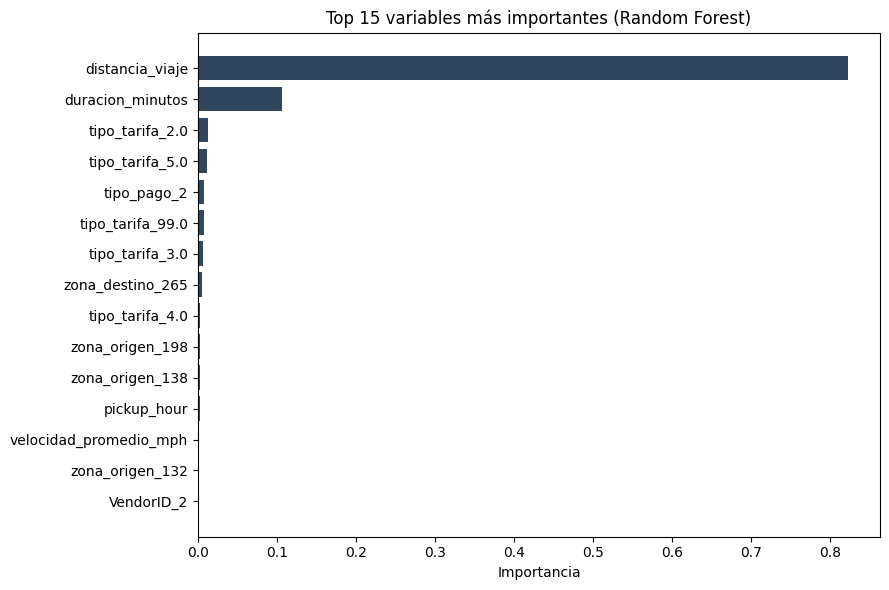

In [9]:
os.makedirs("reports/graficos", exist_ok=True)

# 1. Distribucion del target
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_train, bins=60, color='#F6C90E', edgecolor='white')
ax.set_title("Distribución del objetivo: monto_total ($)")
ax.set_xlabel("Monto total ($)"); ax.set_ylabel("Frecuencia")
fig.tight_layout(); fig.savefig("reports/graficos/distribucion_target.png", dpi=120); plt.show()

# 2. Analisis de errores del Random Forest
residuos = y_test - pred_rf
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, pred_rf, alpha=0.3, color='#30475E', s=10)
lim = [min(y_test.min(), pred_rf.min()), max(y_test.max(), pred_rf.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1)
axes[0].set_title("Random Forest: Predicho vs. Real"); axes[0].set_xlabel("Real ($)"); axes[0].set_ylabel("Predicho ($)")
axes[1].scatter(pred_rf, residuos, alpha=0.3, color='#E63946', s=10)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title("Distribución de residuos"); axes[1].set_xlabel("Predicho ($)"); axes[1].set_ylabel("Residuo")
fig.tight_layout(); fig.savefig("reports/graficos/errores_modelo.png", dpi=120); plt.show()

# 3. Importancia de variables (top 15)
top = importancias.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['variable'], top['importancia'], color='#30475E')
ax.set_title("Top 15 variables más importantes (Random Forest)"); ax.set_xlabel("Importancia")
fig.tight_layout(); fig.savefig("reports/graficos/importancia_variables.png", dpi=120); plt.show()

## 10. Informe de resultados (`reports/informe_resultados.md`)

In [10]:
mejor = df_metricas.sort_values("RMSE").iloc[0]
top5 = importancias.head(5)

def tabla_md(d):
    cols = list(d.columns)
    salida = "| " + " | ".join(cols) + " |\n| " + " | ".join("---" for _ in cols) + " |\n"
    for _, fila in d.iterrows():
        salida += "| " + " | ".join(f"{v:.3f}" if isinstance(v, float) else str(v) for v in fila) + " |\n"
    return salida

os.makedirs("reports", exist_ok=True)
informe = f'''# Informe de Resultados — Predicción de `monto_total` (Yellow Taxi NYC)

## 1. Datos y división
- Entrenamiento: **{X_train.shape[0]:,}** viajes | Prueba: **{X_test.shape[0]:,}** viajes
- División cronológica 80/20 (`shuffle=False` tras ordenar por `fecha_inicio_viaje`).

## 2. Prevención de fuga de datos
Se excluyeron del entrenamiento los componentes de `total_amount` ({", ".join(COLUMNAS_LEAKAGE)})
y las features de costo de EDA ({", ".join(FEATURES_COSTO_EDA)}).

## 3. Métricas de los modelos

{tabla_md(df_metricas)}
**Mejor modelo (por RMSE): {mejor['modelo']}** — MAE={mejor['MAE']:.2f}, RMSE={mejor['RMSE']:.2f}, R2={mejor['R2']:.3f}.

## 4. Variables más influyentes (Random Forest)

{tabla_md(top5)}
## 5. Limitaciones y mejoras futuras
- El muestreo a 100.000 registros es aleatorio (`random_state=42`); puede sesgar la representatividad temporal.
- One-Hot sobre las zonas genera alta dimensionalidad; alternativa: frequency/target encoding.
- Solo se serializa el Random Forest por ser el de mejor desempeño.
'''
with open("reports/informe_resultados.md", "w") as f:
    f.write(informe)
print("Informe escrito en reports/informe_resultados.md")

Informe escrito en reports/informe_resultados.md


## 11. Análisis Crítico y Conclusiones

**Interpretación de resultados:** el **Random Forest** supera ampliamente a la Regresión Lineal. Sobre los 5 meses de datos, el Random Forest alcanza un $R^2 \approx$ **0.96** (MAE $\approx$ **\$2.0**), mientras que la Regresión Lineal queda en $R^2 \approx$ **0.94**. La diferencia refleja que la relación entre las variables del viaje y el costo es **no lineal**, algo que el modelo de ensamble captura mejor.

**Control de fuga de datos:** estas métricas se obtienen **tras excluir todos los componentes que suman `monto_total`** (`tarifa_base`, `propina`, `peajes`, `extra`, `mta_tax`, `improvement_surcharge`, `congestion_surcharge`, `Airport_fee`) y las features de costo derivadas. El $R^2$ se mantiene alto porque la **distancia** y la **duración** son predictores legítimos y dominantes (juntos concentran más del 90 % de la importancia), no porque el modelo "vea" el recibo.

**Limitaciones y mejoras futuras:** el muestreo de 100.000 viajes es aleatorio (`random_state=42`), lo que puede sesgar la representatividad temporal; el One-Hot de zonas genera alta dimensionalidad (una alternativa sería *frequency/target encoding*); y se podría enriquecer el dataset con variables climatológicas o de tráfico en tiempo real. Este notebook reproduce **el mismo proceso y los mismos artefactos** que `src/pipeline.py` + `src/modeling.py`.
